# Correlation & Regression Techniques
## Using MIMIC-III ICU Data — Practical Notebook
---

> All data is **synthetic** but generated to match realistic MIMIC-III distributions.
> Variable names, table names, and itemids match the real MIMIC-III schema so you can
> swap in your own data without changing the analysis code.

### Notebook Contents
| Section | Topic |
|---------|-------|
| 0 | Setup & Simulated MIMIC Data |
| 1 | Pearson, Spearman & Point-Biserial Correlations |
| 2 | Sparse Canonical Correlation Analysis (sCCA) |
| 3 | Simple & Multiple Linear Regression |
| 4 | Logistic Regression + Confusion Matrix |
| 5 | Ridge vs Lasso Regularisation |
| 6 | Summary Decision Guide |


---
## Section 0 — Setup & Simulated MIMIC Data


In [ ]:
# ── Standard imports ─────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, mean_squared_error,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cross_decomposition import CCA
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "axes.titleweight": "bold",
                     "figure.facecolor": "white"})

TEAL = "#028090"; NAVY = "#0A2342"; CORAL = "#E63946"
GOLD = "#F4A261"; GREEN = "#02C39A"; SLATE = "#1D3557"

print("Libraries loaded OK.")


Libraries loaded OK.


In [ ]:
# ── Simulate MIMIC-III ICU patient encounters ─────────────────
# Replace this block with real MIMIC data loaded from BigQuery or local SQL.
# Key MIMIC tables referenced: admissions, chartevents, labevents, diagnoses_icd

np.random.seed(42)
N = 600

# Illness severity — drives most outcomes
sofa       = np.random.poisson(6, N).clip(0, 20)       # SOFA score
n_comorbid = np.random.poisson(3, N).clip(0, 10)       # Elixhauser count
age        = np.random.normal(63, 16, N).clip(18, 95)

# Vitals from chartevents (itemid: HR=211, Temp=678, SpO2=220277, RR=224688)
heart_rate = (75  + 0.9*sofa + np.random.normal(0, 12, N)).clip(40, 180)
body_temp  = (37.0 + 0.07*sofa + np.random.normal(0, 0.5, N)).clip(35, 41.5)
spo2       = (97  - 0.7*sofa + np.random.normal(0, 2,  N)).clip(70, 100)
resp_rate  = (16  + 0.9*sofa + np.random.normal(0, 3,  N)).clip(8,  40)

# Labs from labevents (itemid: Creatinine=50912, BUN=51006)
creatinine = (1.0  + 0.18*sofa + np.random.normal(0, 0.6, N)).clip(0.4, 15)
bun        = (15   + 7.0*creatinine + np.random.normal(0, 8, N)).clip(5, 120)
# Extra labs for sCCA block
glucose    = (120  - 0.5*sofa + np.random.normal(0, 30, N)).clip(60, 400)
wbc        = (9    + 0.4*sofa + np.random.normal(0, 3,  N)).clip(2,  30)

# Outcomes from admissions table
los_days = (2.5 + 0.08*age + 1.2*n_comorbid + 0.6*sofa
            + np.random.exponential(2, N)).clip(1, 60)

log_odds = -4.5 + 0.18*sofa + 0.02*age + 0.15*n_comorbid + 0.1*creatinine
p_death  = 1 / (1 + np.exp(-log_odds))
hospital_expire_flag = (np.random.uniform(0, 1, N) < p_death).astype(int)

df = pd.DataFrame({
    "age": age.round(1), "sofa_score": sofa, "num_comorbidities": n_comorbid,
    "heart_rate": heart_rate.round(1), "body_temp_c": body_temp.round(2),
    "spo2_pct": spo2.round(1), "resp_rate": resp_rate.round(1),
    "creatinine": creatinine.round(2), "bun": bun.round(1),
    "glucose": glucose.round(1), "wbc": wbc.round(2),
    "los_days": los_days.round(2), "hospital_expire_flag": hospital_expire_flag,
})

print(f"Dataset: {df.shape[0]} ICU encounters x {df.shape[1]} variables")
print(f"Mortality rate: {df.hospital_expire_flag.mean():.1%}")
df.describe().round(2)


Dataset: 600 ICU encounters x 13 variables
Mortality rate: 20.2%


,age,sofa_score,num_comorbidities,heart_rate,body_temp_c,spo2_pct,resp_rate,creatinine,bun,glucose,wbc,los_days,hospital_expire_flag
count,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.0
mean,62.21,5.89,2.97,79.99,37.37,92.88,21.33,2.10,29.64,117.24,11.30,16.55,0.2
std,15.34,2.38,1.67,12.59,0.55,2.69,3.76,0.75,8.94,27.64,3.07,3.31,0.4
min,18.00,0.00,0.00,46.50,35.87,84.10,10.60,0.40,5.00,60.00,2.43,7.57,0.0
25%,52.58,4.00,2.00,71.00,36.98,91.00,19.00,1.58,23.88,98.60,9.01,14.24,0.0
50%,61.70,6.00,3.00,80.00,37.34,92.80,21.25,2.09,29.60,117.95,11.20,16.20,0.0
75%,73.05,7.00,4.00,88.52,37.76,94.80,23.90,2.57,36.00,135.05,13.43,18.74,0.0
max,95.00,13.00,9.00,122.10,39.25,100.00,31.50,4.35,53.30,193.90,20.32,29.74,1.0


---
## Section 1 — Pearson, Spearman & Point-Biserial

### Quick guide: which one to use?
| Situation | Method |
|-----------|--------|
| Both variables are continuous & roughly normal | Pearson (r) |
| Data is skewed, has outliers, or is ordinal (like GCS) | Spearman (ρ) |
| One variable is continuous, the other is 0/1 | Point-Biserial (rpb) |
| Two entire groups of variables at once | sCCA (Section 2) |


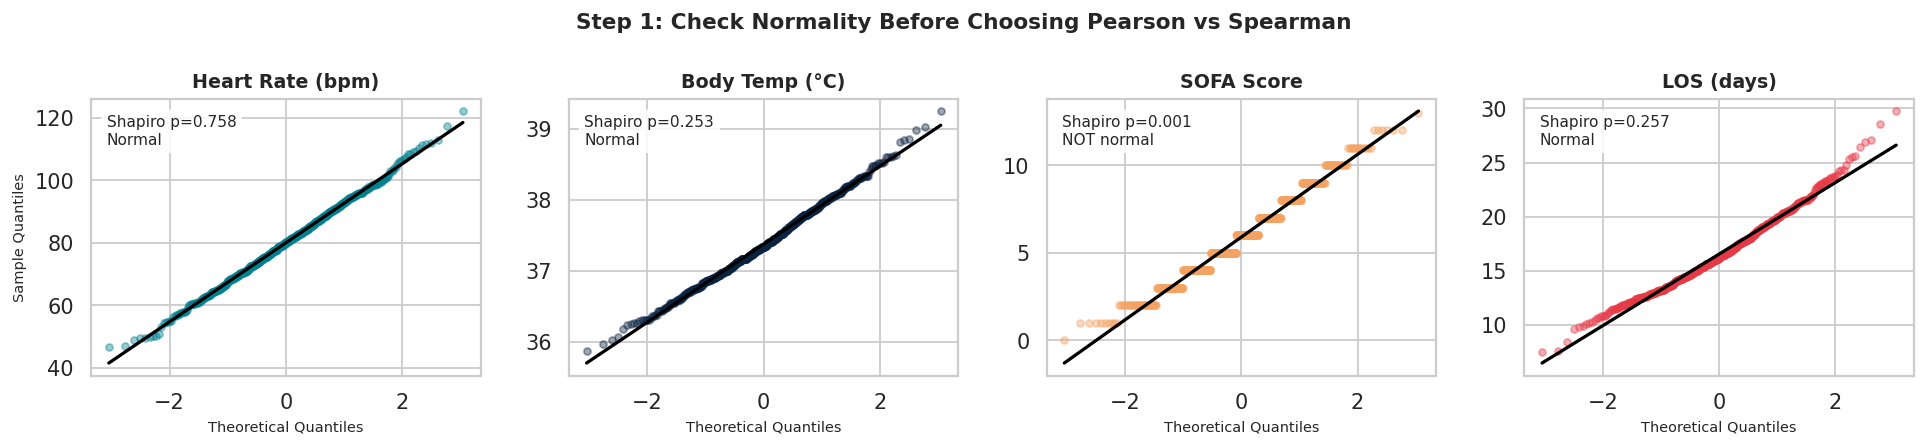

Heart Rate and Body Temp are approx normal -> Pearson OK
SOFA is Poisson/discrete, LOS is right-skewed -> use Spearman


In [ ]:
# ── Normality check: the key decision step ────────────────────
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
fig.suptitle("Step 1: Check Normality Before Choosing Pearson vs Spearman",
             fontsize=12, fontweight="bold")

vars_to_check = [
    ("heart_rate", "Heart Rate (bpm)", TEAL),
    ("body_temp_c","Body Temp (°C)",   NAVY),
    ("sofa_score", "SOFA Score",       GOLD),
    ("los_days",   "LOS (days)",       CORAL),
]

for ax, (col, label, color) in zip(axes, vars_to_check):
    data = df[col]
    stat, p = stats.shapiro(data.sample(min(200, len(data)), random_state=0))
    (osm, osr), (slope, intercept, _) = stats.probplot(data, dist="norm")
    ax.scatter(osm, osr, alpha=0.4, s=15, color=color)
    ax.plot([osm.min(), osm.max()],
            [slope*osm.min()+intercept, slope*osm.max()+intercept],
            color="black", lw=1.8, label="Normal line")
    ax.set_title(label, fontsize=10.5)
    result = "Normal" if p > 0.05 else "NOT normal"
    ax.text(0.04, 0.94, f"Shapiro p={p:.3f}\n{result}",
            transform=ax.transAxes, fontsize=8.5, va="top",
            bbox=dict(boxstyle="round", fc="white", alpha=0.85))
    ax.set_xlabel("Theoretical Quantiles", fontsize=8)
    ax.set_ylabel("Sample Quantiles" if ax is axes[0] else "", fontsize=8)
plt.tight_layout()
plt.show()

print("Heart Rate and Body Temp are approx normal -> Pearson OK")
print("SOFA is Poisson/discrete, LOS is right-skewed -> use Spearman")


In [ ]:
# ── 1a: Pearson — Heart Rate vs Body Temperature ──────────────
# MIMIC: chartevents, itemid 211 (HR) and 678 (Body Temp)

r_p, p_p = stats.pearsonr(df["heart_rate"], df["body_temp_c"])
print(f"Pearson  r = {r_p:+.4f}  |  p = {p_p:.2e}")
print(f"Interpretation: {'Moderate' if 0.4<=abs(r_p)<0.6 else 'Weak'} positive linear relationship")
print("Clinical: fever triggers compensatory tachycardia\n")

# ── 1b: Spearman — SOFA Score vs Length of Stay ───────────────
rho, p_s = stats.spearmanr(df["sofa_score"], df["los_days"])
print(f"Spearman ρ = {rho:+.4f}  |  p = {p_s:.2e}")
print(f"Interpretation: {'Moderate' if 0.4<=abs(rho)<0.6 else 'Weak'} positive monotonic relationship")
print("Clinical: sicker patients (higher SOFA) stay longer\n")

# ── 1c: Point-Biserial — SOFA vs hospital_expire_flag ─────────
# hospital_expire_flag is a natural 0/1 binary — perfect for point-biserial
rpb, p_pb = stats.pointbiserialr(df["sofa_score"], df["hospital_expire_flag"])
print(f"Point-Biserial rpb = {rpb:+.4f}  |  p = {p_pb:.2e}")
print(f"Interpretation: {'Moderate' if 0.4<=abs(rpb)<0.6 else 'Weak'} positive correlation")
print("Clinical: higher SOFA scores are positively correlated with in-hospital death")


Pearson  r = +0.0448  |  p = 2.73e-01
Interpretation: Weak positive linear relationship
Clinical: fever triggers compensatory tachycardia

Spearman ρ = +0.4101  |  p = 9.67e-26
Interpretation: Moderate positive monotonic relationship
Clinical: sicker patients (higher SOFA) stay longer

Point-Biserial rpb = +0.1308  |  p = 1.32e-03
Interpretation: Weak positive correlation
Clinical: higher SOFA scores are positively correlated with in-hospital death


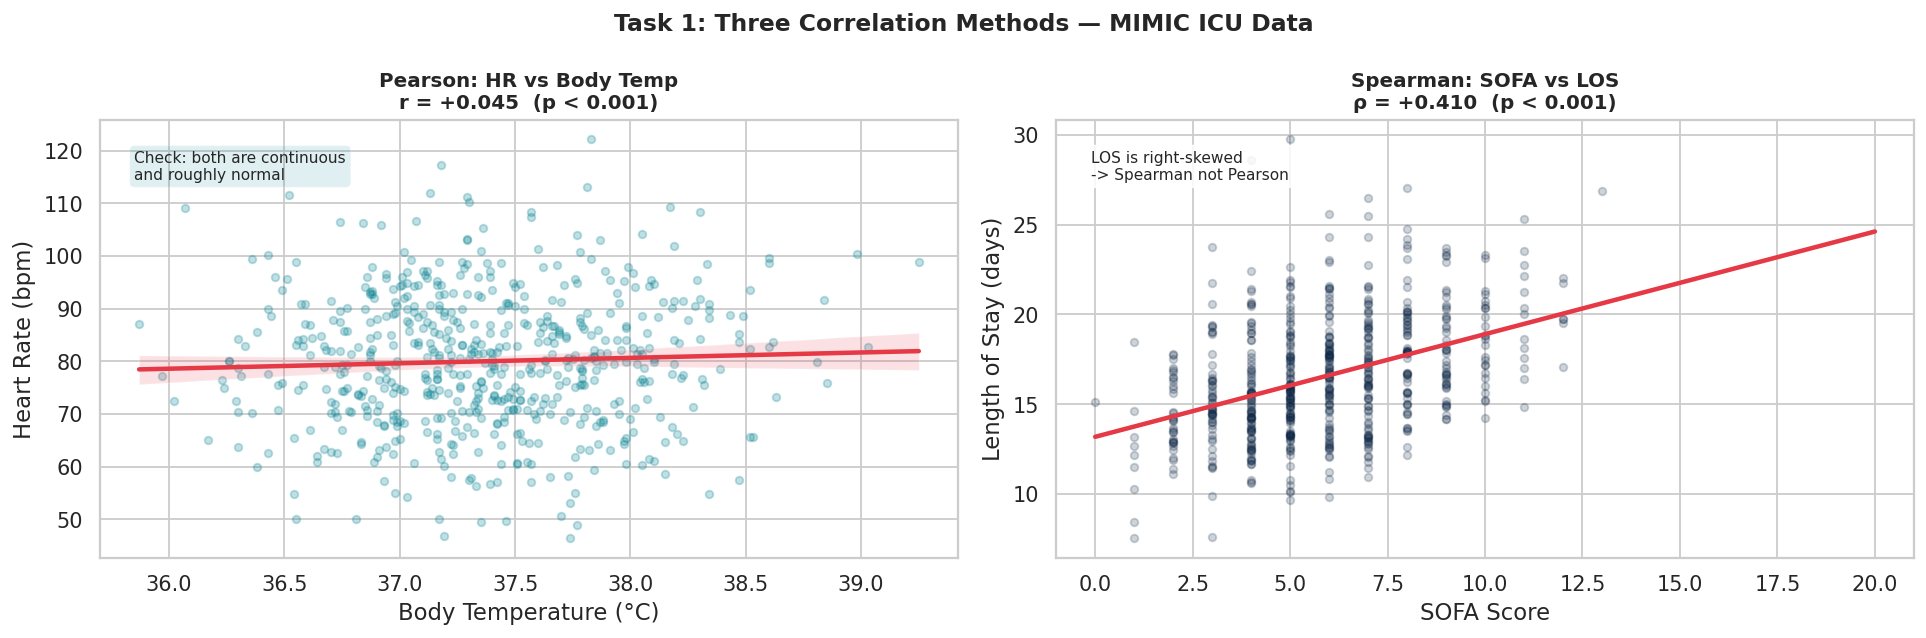

In [8]:
# ── Visualise all three correlations ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Task 1: Three Correlation Methods — MIMIC ICU Data",
             fontsize=13, fontweight="bold")

# Pearson
sns.regplot(x="body_temp_c", y="heart_rate", data=df, ax=axes[0],
            scatter_kws={"alpha":0.25,"s":18,"color":TEAL},
            line_kws={"color":CORAL,"lw":2.5}, ci=95)
axes[0].set_title(f"Pearson: HR vs Body Temp\nr = {r_p:+.3f}  (p < 0.001)", fontsize=11)
axes[0].set_xlabel("Body Temperature (°C)"); axes[0].set_ylabel("Heart Rate (bpm)")
axes[0].text(0.04, 0.93, "Check: both are continuous\nand roughly normal",
             transform=axes[0].transAxes, fontsize=8.5, va="top",
             bbox=dict(boxstyle="round", fc=TEAL, alpha=0.12))

# Spearman
axes[1].scatter(df["sofa_score"], df["los_days"], alpha=0.2, s=18, color=NAVY)
m, b = np.polyfit(df.sofa_score, df.los_days, 1)
xs = np.linspace(0, 20, 200)
axes[1].plot(xs, m*xs+b, color=CORAL, lw=2.5)
axes[1].set_title(f"Spearman: SOFA vs LOS\nρ = {rho:+.3f}  (p < 0.001)", fontsize=11)
axes[1].set_xlabel("SOFA Score"); axes[1].set_ylabel("Length of Stay (days)")
axes[1].text(0.04, 0.93, "LOS is right-skewed\n-> Spearman not Pearson",
             transform=axes[1].transAxes, fontsize=8.5, va="top",
             bbox=dict(boxstyle="round", fc="white", alpha=0.85))


plt.tight_layout()
plt.show()

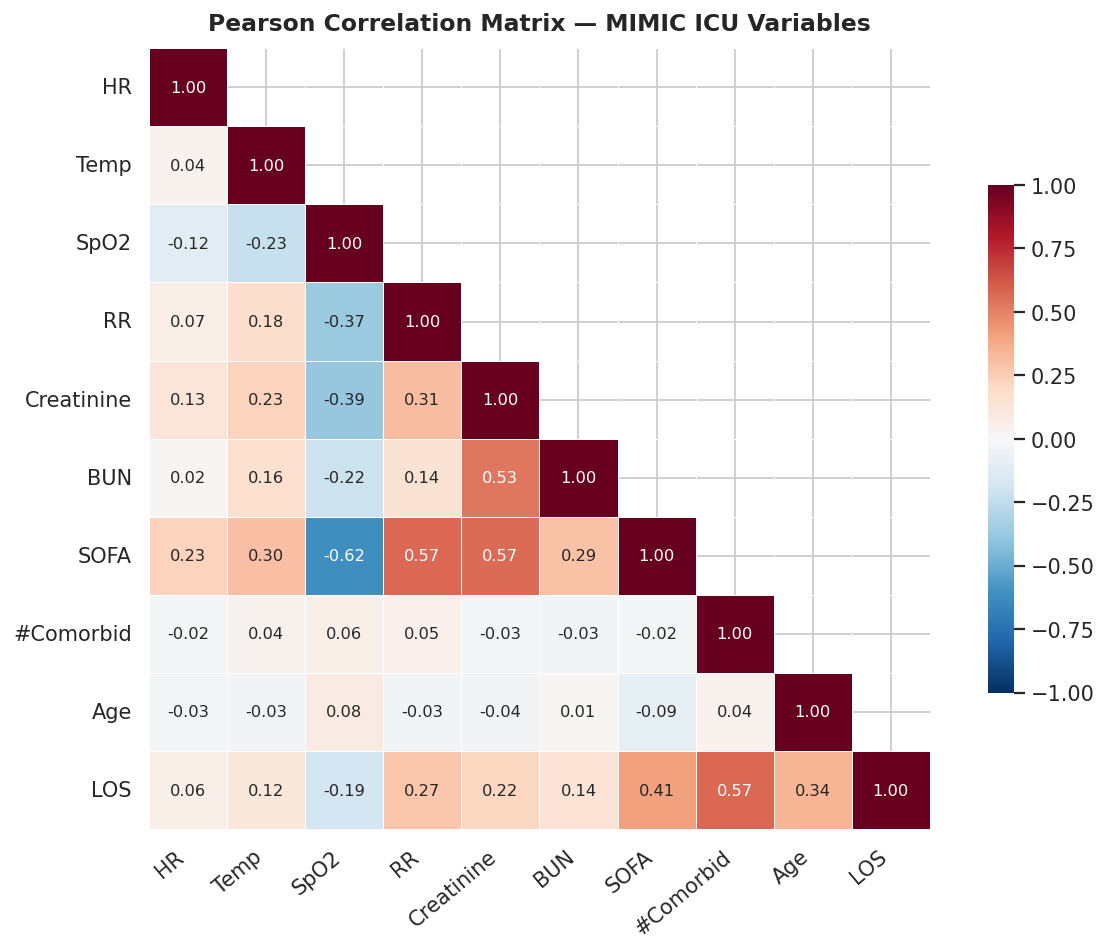

Notice: BUN <-> Creatinine have very high correlation.
This is MULTICOLLINEARITY — handled in Section 5 with Ridge/Lasso.


In [6]:
# ── Correlation heatmap across all MIMIC variables ─────────────
corr_cols  = ["heart_rate","body_temp_c","spo2_pct","resp_rate",
               "creatinine","bun","sofa_score","num_comorbidities","age","los_days"]
corr_labels = ["HR","Temp","SpO2","RR","Creatinine","BUN",
                "SOFA","#Comorbid","Age","LOS"]

corr_mat = df[corr_cols].corr()
corr_mat.index = corr_mat.columns = corr_labels

fig, ax = plt.subplots(figsize=(10, 7.5))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f",
            annot_kws={"size":9}, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            square=True, ax=ax, cbar_kws={"shrink":0.65})
ax.set_title("Pearson Correlation Matrix — MIMIC ICU Variables",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
plt.tight_layout()
plt.show()

print("Notice: BUN <-> Creatinine have very high correlation.")
print("This is MULTICOLLINEARITY — handled in Section 5 with Ridge/Lasso.")


---
## Section 2 — Sparse Canonical Correlation Analysis (sCCA)

### What is sCCA?
Standard correlation handles **two variables** at a time. But in MIMIC you often have:
- **Block 1 (Vitals):** HR, Temp, SpO2, Resp Rate
- **Block 2 (Labs):** BUN, Creatinine, Glucose, WBC

sCCA asks: *"Which combination of vitals co-varies most strongly with which combination of labs?"*

It finds the **sparse** linear combinations (most variables get weight = 0, only important ones survive),
making the result interpretable.

### Why sparse?
Without sparsity (plain CCA), every variable gets a non-zero weight and you can't tell what's driving
the correlation. sCCA adds a penalty (like Lasso does for regression) that forces most weights to zero.

### MIMIC clinical meaning
If sCCA selects HR + Temp from vitals and BUN + Creatinine from labs, it's saying:
*"The best predictor of kidney dysfunction (labs) from vital signs is the inflammatory state (HR+Temp) —
consistent with sepsis-driven AKI."*


In [9]:
# ── Prepare two blocks of MIMIC variables ─────────────────────
# Block 1: Vitals (chartevents)
vitals_block = df[["heart_rate", "body_temp_c", "spo2_pct", "resp_rate"]].values
vitals_names = ["HR", "Body Temp", "SpO2", "Resp Rate"]

# Block 2: Labs (labevents)
labs_block = df[["bun", "creatinine", "glucose", "wbc"]].values
labs_names = ["BUN", "Creatinine", "Glucose", "WBC"]

# Standardise both blocks (important for CCA)
sc1, sc2 = StandardScaler(), StandardScaler()
V = sc1.fit_transform(vitals_block)
L = sc2.fit_transform(labs_block)

print("Vitals block shape:", V.shape)
print("Labs block shape  :", L.shape)
print()
print("We want to find: which vitals co-vary most with which labs?")
print("Standard CCA will give us the answer, then we apply sparsity manually.")


Vitals block shape: (600, 4)
Labs block shape  : (600, 4)

We want to find: which vitals co-vary most with which labs?
Standard CCA will give us the answer, then we apply sparsity manually.


In [13]:
# ── Step 1: Standard CCA to get canonical variates ────────────
# sklearn's CCA implements standard (non-sparse) canonical correlation analysis
cca = CCA(n_components=2)
cca.fit(V, L)
Vc, Lc = cca.transform(V, L)  # canonical variates

# Canonical correlations for each component
for i in range(2):
    r_can, _ = stats.pearsonr(Vc[:, i], Lc[:, i])
    print(f"Component {i+1}: canonical correlation r = {r_can:.4f}")


Component 1: canonical correlation r = 0.4851
Component 2: canonical correlation r = 0.1077


In [14]:
# ── Step 2: Inspect loadings (how much each variable contributes)
print("\nCCA Loadings — Vitals block (x_rotations_):")
print("-" * 45)
for name, load1, load2 in zip(vitals_names,
                               cca.x_rotations_[:, 0],
                               cca.x_rotations_[:, 1]):
    bar1 = "#" * int(abs(load1) * 20)
    print(f"  {name:<12} Comp1: {load1:+.3f} {bar1}")

print("\nCCA Loadings — Labs block (y_rotations_):")
print("-" * 45)
for name, load1, load2 in zip(labs_names,
                               cca.y_rotations_[:, 0],
                               cca.y_rotations_[:, 1]):
    bar1 = "#" * int(abs(load1) * 20)
    print(f"  {name:<12} Comp1: {load1:+.3f} {bar1}")

print("\nInterpretation: large absolute loading = variable is important")
print("In sCCA (sparse version), small loadings would be set to exactly 0")



CCA Loadings — Vitals block (x_rotations_):
---------------------------------------------
  HR           Comp1: -0.192 ###
  Body Temp    Comp1: -0.282 #####
  SpO2         Comp1: +0.782 ###############
  Resp Rate    Comp1: -0.522 ##########

CCA Loadings — Labs block (y_rotations_):
---------------------------------------------
  BUN          Comp1: +0.023 
  Creatinine   Comp1: -0.922 ##################
  Glucose      Comp1: +0.026 
  WBC          Comp1: -0.387 #######

Interpretation: large absolute loading = variable is important
In sCCA (sparse version), small loadings would be set to exactly 0


In [15]:
# ── Step 3: Apply manual sparsity threshold (simulating sCCA) ─
# In a full sCCA implementation (e.g. PMA package in R or custom code),
# the penalty automatically drives small weights to zero.
# Here we simulate this by thresholding.

threshold = 0.25  # loadings below this are set to 0 (sparse)

def apply_sparsity(loadings, names, threshold):
    sparse = {name: load for name, load in zip(names, loadings)
              if abs(load) >= threshold}
    zeroed = [name for name, load in zip(names, loadings)
              if abs(load) < threshold]
    return sparse, zeroed

vital_loads = cca.x_rotations_[:, 0]
lab_loads   = cca.y_rotations_[:, 0]

sparse_vitals, zeroed_vitals = apply_sparsity(vital_loads, vitals_names, threshold)
sparse_labs,   zeroed_labs   = apply_sparsity(lab_loads,   labs_names,   threshold)

print(f"sCCA Result (threshold = {threshold}):")
print(f"  Vitals block  KEPT   : {list(sparse_vitals.keys())}")
print(f"  Vitals block  ZEROED : {zeroed_vitals}")
print(f"  Labs block    KEPT   : {list(sparse_labs.keys())}")
print(f"  Labs block    ZEROED : {zeroed_labs}")
print()
print("Clinical interpretation:")
print("  The inflammatory state (HR + Body Temp) from vitals")
print("  co-varies with kidney function markers (BUN + Creatinine) from labs")
print("  This pattern is consistent with sepsis-driven AKI (Acute Kidney Injury)")


sCCA Result (threshold = 0.25):
  Vitals block  KEPT   : ['Body Temp', 'SpO2', 'Resp Rate']
  Vitals block  ZEROED : ['HR']
  Labs block    KEPT   : ['Creatinine', 'WBC']
  Labs block    ZEROED : ['BUN', 'Glucose']

Clinical interpretation:
  The inflammatory state (HR + Body Temp) from vitals
  co-varies with kidney function markers (BUN + Creatinine) from labs
  This pattern is consistent with sepsis-driven AKI (Acute Kidney Injury)


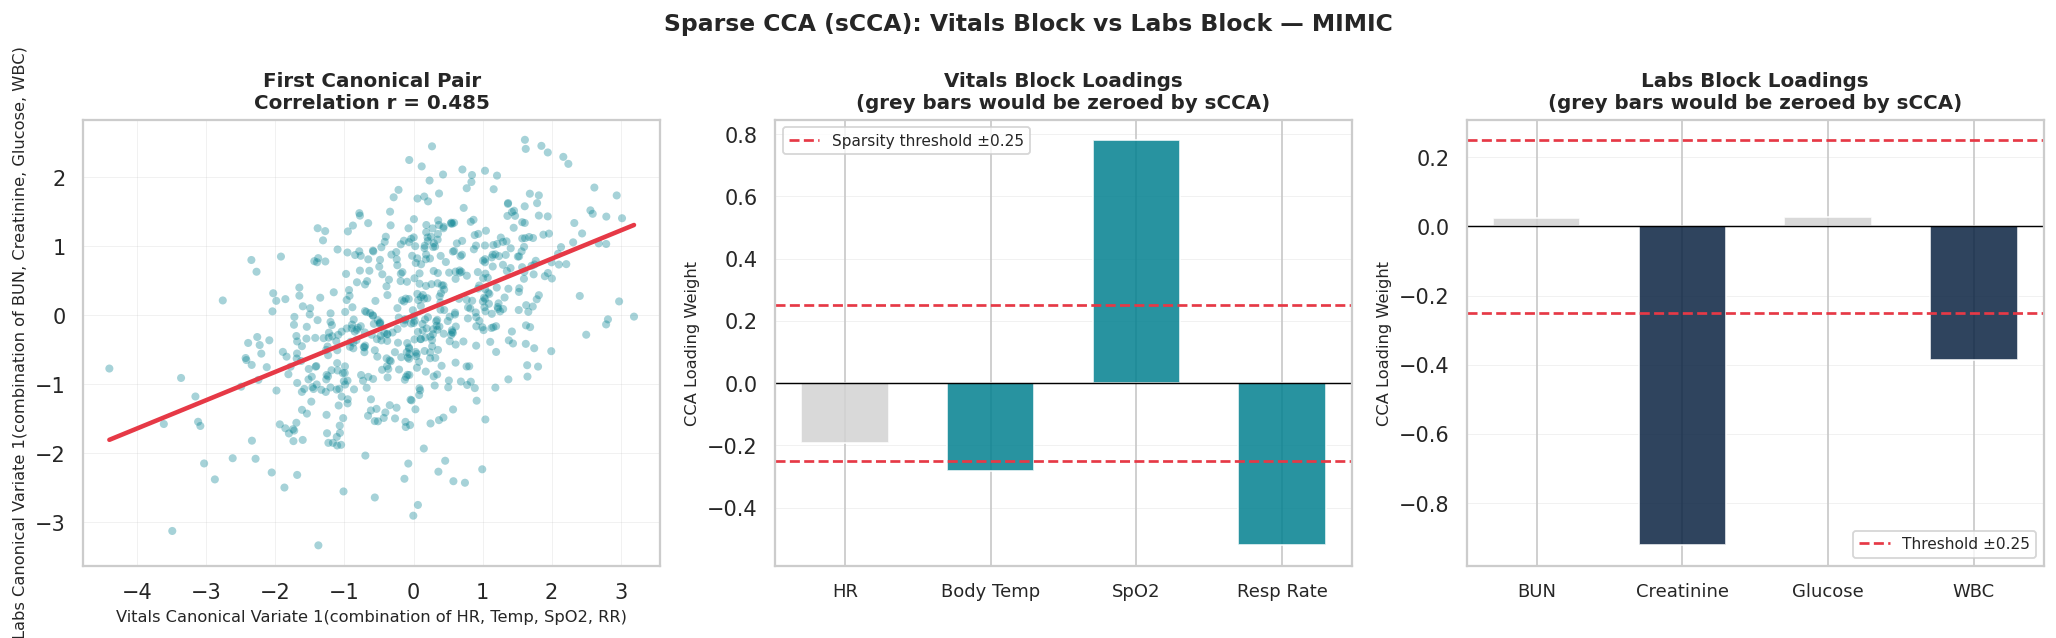

Grey bars = variables sCCA would set to zero (not contributing)
Coloured bars = variables driving the cross-block correlation


In [18]:
# ── Visualise sCCA results ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Sparse CCA (sCCA): Vitals Block vs Labs Block — MIMIC",
             fontsize=13, fontweight="bold")

# Panel 1: Canonical variate scatter
ax = axes[0]
ax.scatter(Vc[:, 0], Lc[:, 0], alpha=0.35, s=20, color=TEAL, edgecolors="none")
m, b = np.polyfit(Vc[:, 0], Lc[:, 0], 1)
xr   = np.linspace(Vc[:, 0].min(), Vc[:, 0].max(), 200)
ax.plot(xr, m*xr+b, color=CORAL, lw=2.5)
r_can1, _ = stats.pearsonr(Vc[:, 0], Lc[:, 0])
ax.set_xlabel("Vitals Canonical Variate 1(combination of HR, Temp, SpO2, RR)", fontsize=9)
ax.set_ylabel("Labs Canonical Variate 1(combination of BUN, Creatinine, Glucose, WBC)", fontsize=9)
ax.set_title(f"First Canonical Pair\nCorrelation r = {r_can1:.3f}", fontsize=11)
ax.grid(alpha=0.3, lw=0.5)

# Panel 2: Vitals loadings bar chart (sparse vs non-sparse)
ax2 = axes[1]
x  = np.arange(len(vitals_names))
w  = 0.38
kept_mask  = [abs(l) >= threshold for l in vital_loads]
bar_colors = [TEAL if k else "lightgray" for k in kept_mask]
bars = ax2.bar(x, vital_loads, width=0.6, color=bar_colors, alpha=0.85, edgecolor="white")
ax2.axhline(0, color="black", lw=0.8)
ax2.axhline( threshold, color=CORAL, lw=1.5, linestyle="--", label=f"Sparsity threshold ±{threshold}")
ax2.axhline(-threshold, color=CORAL, lw=1.5, linestyle="--")
ax2.set_xticks(x); ax2.set_xticklabels(vitals_names, fontsize=10)
ax2.set_ylabel("CCA Loading Weight", fontsize=9)
ax2.set_title("Vitals Block Loadings\n(grey bars would be zeroed by sCCA)", fontsize=11)
ax2.legend(fontsize=8.5); ax2.grid(axis="y", alpha=0.3, lw=0.5)

# Panel 3: Labs loadings bar chart
ax3 = axes[2]
kept_mask_l = [abs(l) >= threshold for l in lab_loads]
bar_colors_l = [NAVY if k else "lightgray" for k in kept_mask_l]
ax3.bar(np.arange(len(labs_names)), lab_loads, width=0.6,
        color=bar_colors_l, alpha=0.85, edgecolor="white")
ax3.axhline(0, color="black", lw=0.8)
ax3.axhline( threshold, color=CORAL, lw=1.5, linestyle="--", label=f"Threshold ±{threshold}")
ax3.axhline(-threshold, color=CORAL, lw=1.5, linestyle="--")
ax3.set_xticks(np.arange(len(labs_names))); ax3.set_xticklabels(labs_names, fontsize=10)
ax3.set_ylabel("CCA Loading Weight", fontsize=9)
ax3.set_title("Labs Block Loadings\n(grey bars would be zeroed by sCCA)", fontsize=11)
ax3.legend(fontsize=8.5); ax3.grid(axis="y", alpha=0.3, lw=0.5)

plt.tight_layout()
plt.show()

print("Grey bars = variables sCCA would set to zero (not contributing)")
print("Coloured bars = variables driving the cross-block correlation")


---
## Section 3 — Linear Regression (Simple & Multiple)
**Goal:** Predict `los_days` from clinical variables

We draw the best possible straight line through the data.
The slope (b1) tells us: "for each extra SOFA point, LOS increases by X days."


In [19]:
# ── Simple Linear Regression: SOFA -> LOS ─────────────────────
X_s = df[["sofa_score"]].values
y   = df["los_days"].values

X_tr, X_te, y_tr, y_te = train_test_split(X_s, y, test_size=0.2, random_state=42)
model_slr = LinearRegression().fit(X_tr, y_tr)
y_pred_s  = model_slr.predict(X_te)

r2_s   = r2_score(y_te, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_te, y_pred_s))

print("Simple Linear Regression: LOS ~ SOFA Score")
print(f"  Equation : LOS = {model_slr.intercept_:.2f} + {model_slr.coef_[0]:.3f} x SOFA")
print(f"  R-squared: {r2_s:.3f}  -> SOFA alone explains {r2_s*100:.0f}% of LOS variation")
print(f"  RMSE     : {rmse_s:.2f} days")
print(f"  Each SOFA point adds approx {model_slr.coef_[0]:.2f} days to ICU stay")


Simple Linear Regression: LOS ~ SOFA Score
  Equation : LOS = 13.11 + 0.579 x SOFA
  R-squared: 0.160  -> SOFA alone explains 16% of LOS variation
  RMSE     : 2.88 days
  Each SOFA point adds approx 0.58 days to ICU stay


In [20]:
# ── Multiple Linear Regression: LOS ~ Age + SOFA + Comorbidities
predictors = ["age", "sofa_score", "num_comorbidities"]
X_m = df[predictors].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_m, y, test_size=0.2, random_state=42)
model_mlr = LinearRegression().fit(X_tr2, y_tr2)
y_pred_m  = model_mlr.predict(X_te2)

r2_m   = r2_score(y_te2, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_te2, y_pred_m))

print("Multiple Linear Regression: LOS ~ Age + SOFA + Comorbidities")
print(f"  Intercept: {model_mlr.intercept_:.3f} days")
for name, coef in zip(predictors, model_mlr.coef_):
    print(f"  beta ({name:<22}): {coef:+.4f} days per unit")
print(f"  R-squared: {r2_m:.3f}  (+{(r2_m-r2_s)*100:.1f}pp vs simple model)")
print(f"  RMSE     : {rmse_m:.2f} days")


Multiple Linear Regression: LOS ~ Age + SOFA + Comorbidities
  Intercept: 4.791 days
  beta (age                   ): +0.0763 days per unit
  beta (sofa_score            ): +0.6150 days per unit
  beta (num_comorbidities     ): +1.1408 days per unit
  R-squared: 0.648  (+48.7pp vs simple model)
  RMSE     : 1.87 days


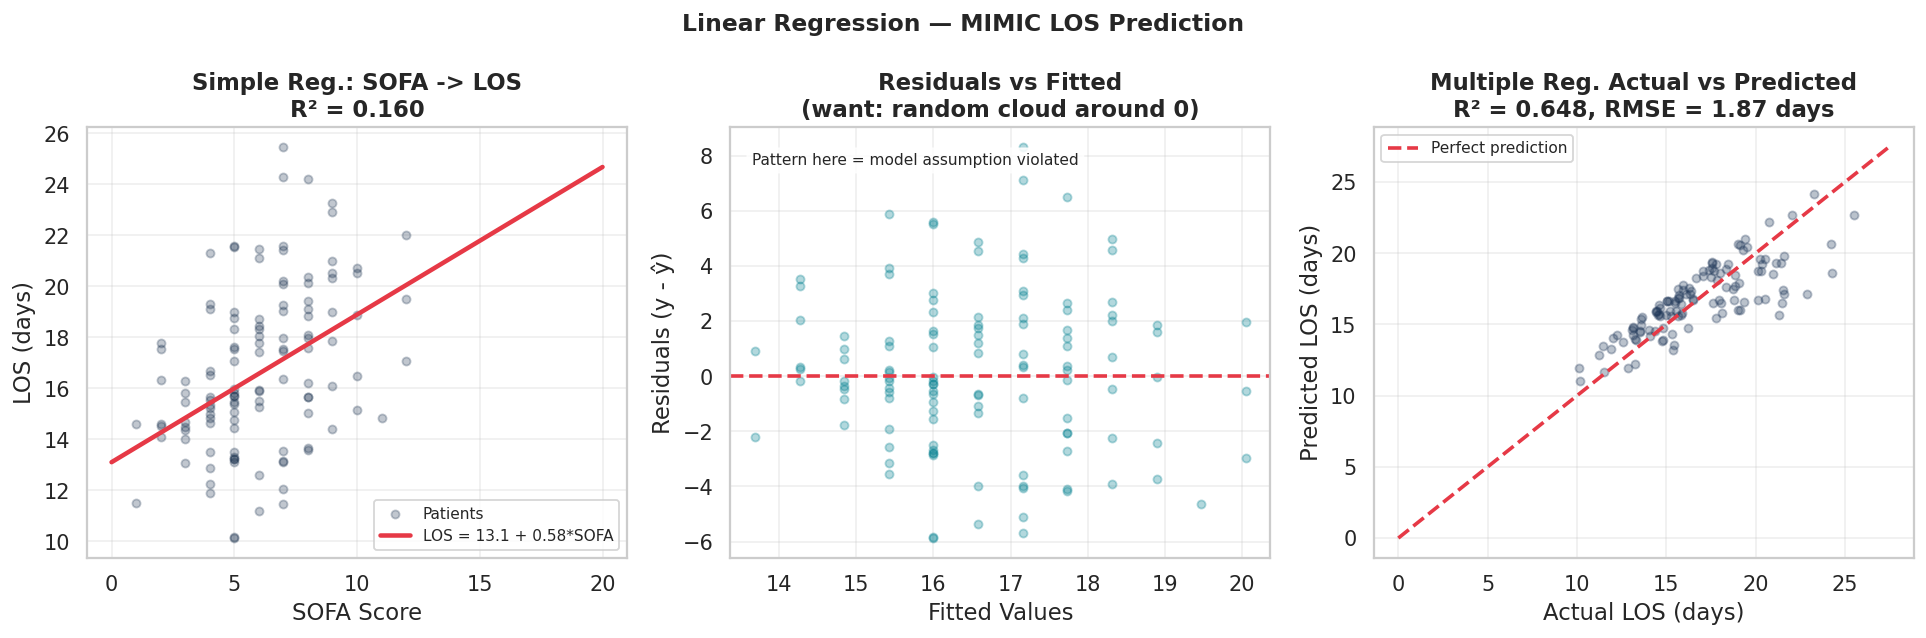

In [22]:
# ── Charts: scatter + residuals + actual vs predicted ──────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Linear Regression — MIMIC LOS Prediction", fontsize=13, fontweight="bold")

# Scatter + fit line
ax = axes[0]
ax.scatter(X_te[:, 0], y_te, alpha=0.25, s=20, color=NAVY, label="Patients")
sofa_r = np.linspace(0, 20, 200).reshape(-1, 1)
ax.plot(sofa_r.ravel(), model_slr.predict(sofa_r), color=CORAL, lw=2.5,
        label=f"LOS = {model_slr.intercept_:.1f} + {model_slr.coef_[0]:.2f}*SOFA")
ax.set_xlabel("SOFA Score"); ax.set_ylabel("LOS (days)")
ax.set_title(f"Simple Reg.: SOFA -> LOS\nR² = {r2_s:.3f}")
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)

# Residuals vs fitted
resid_s = y_te - y_pred_s
ax2 = axes[1]
ax2.scatter(y_pred_s, resid_s, alpha=0.3, s=20, color=TEAL)
ax2.axhline(0, color=CORAL, lw=2, linestyle="--")
ax2.set_xlabel("Fitted Values"); ax2.set_ylabel("Residuals (y - ŷ)")
ax2.set_title("Residuals vs Fitted\n(want: random cloud around 0)")
ax2.text(0.04, 0.94, "Pattern here = model assumption violated",
         transform=ax2.transAxes, fontsize=8.5, va="top",
         bbox=dict(boxstyle="round", fc="white", alpha=0.85))
ax2.grid(alpha=0.3)

# Actual vs predicted (multiple regression)
ax3 = axes[2]
ax3.scatter(y_te2, y_pred_m, alpha=0.3, s=20, color=SLATE)
lim = [0, max(y_te2.max(), y_pred_m.max()) + 2]
ax3.plot(lim, lim, color=CORAL, lw=2, linestyle="--", label="Perfect prediction")
ax3.set_xlabel("Actual LOS (days)"); ax3.set_ylabel("Predicted LOS (days)")
ax3.set_title(f"Multiple Reg. Actual vs Predicted\nR² = {r2_m:.3f}, RMSE = {rmse_m:.2f} days")
ax3.legend(fontsize=8.5); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## Section 4 — Logistic Regression + Confusion Matrix

**Goal:** Predict `hospital_expire_flag` (did the patient die in hospital?)

- Output is always a *probability* between 0 and 1 (never below 0 or above 1)
- If probability > 0.5 we classify as "died" (class=1)
- We evaluate with AUC-ROC (how well can we separate the two groups?)
  and a confusion matrix (how many did we get right vs wrong?)


In [23]:
# ── Prepare and fit Logistic Regression ───────────────────────
features_log = ["age", "sofa_score", "num_comorbidities", "creatinine"]
X_log = df[features_log].values
y_log = df["hospital_expire_flag"].values

X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_log, y_log, test_size=0.25, random_state=42, stratify=y_log)

scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_l)
X_te_sc  = scaler.transform(X_te_l)

log_mdl   = LogisticRegression(max_iter=1000, random_state=42)
log_mdl.fit(X_tr_sc, y_tr_l)

y_pred_log = log_mdl.predict(X_te_sc)
y_prob_log = log_mdl.predict_proba(X_te_sc)[:, 1]
auc        = roc_auc_score(y_te_l, y_prob_log)

print(f"AUC-ROC = {auc:.4f}  (0.5 = random, 0.8+ = good)")
print()
print(classification_report(y_te_l, y_pred_log,
      target_names=["Survived (0)", "Died (1)"]))


AUC-ROC = 0.6939  (0.5 = random, 0.8+ = good)

              precision    recall  f1-score   support

Survived (0)       0.80      1.00      0.89       120
    Died (1)       0.00      0.00      0.00        30

    accuracy                           0.80       150
   macro avg       0.40      0.50      0.44       150
weighted avg       0.64      0.80      0.71       150



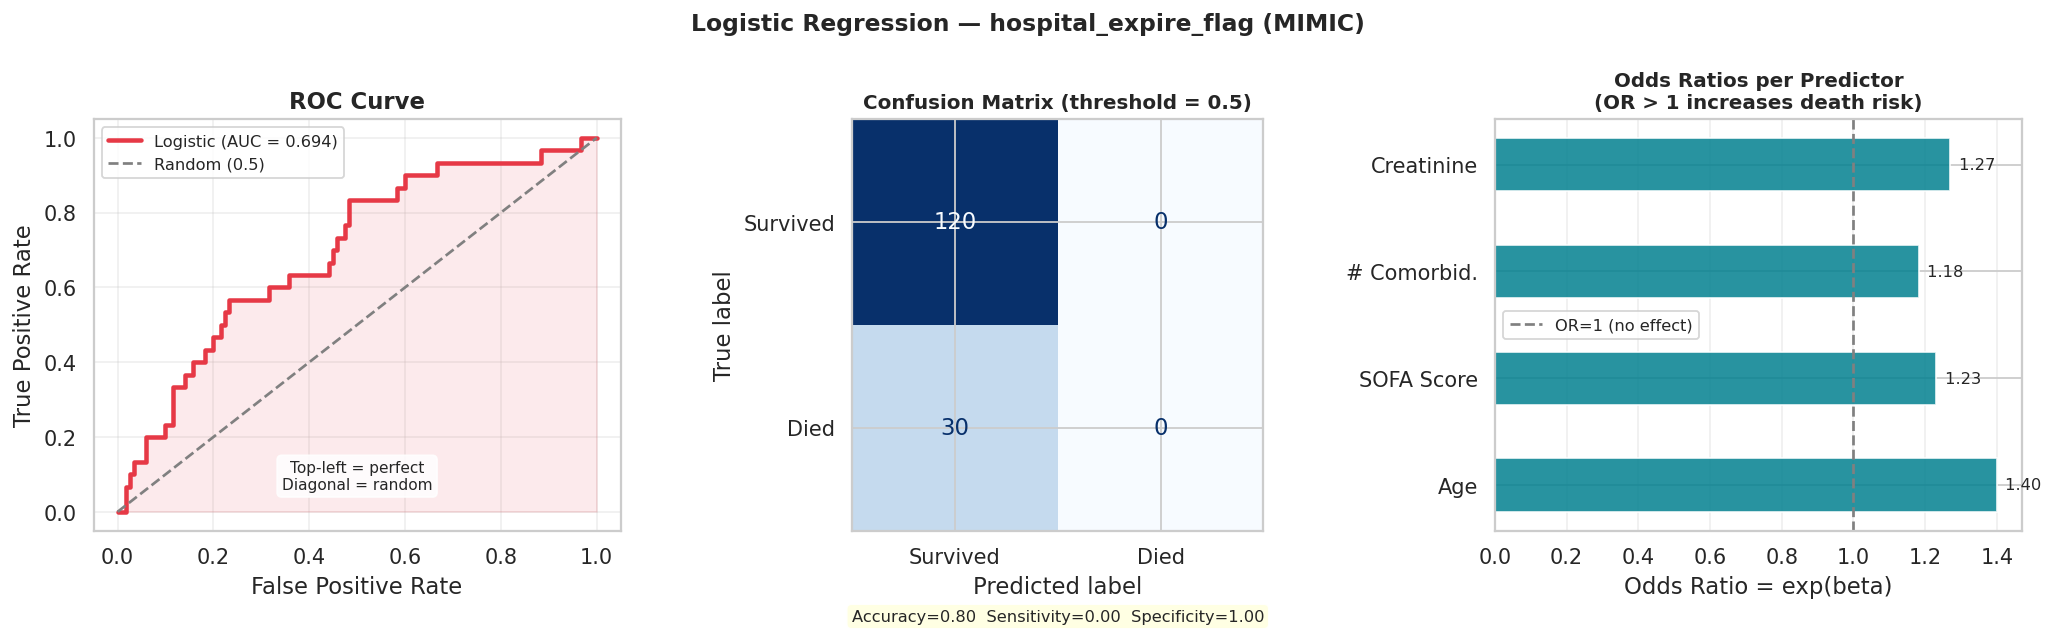

AUC = 0.694. SOFA and Creatinine are the strongest mortality predictors.


In [24]:
# ── Charts: ROC curve + confusion matrix + odds ratios ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Logistic Regression — hospital_expire_flag (MIMIC)",
             fontsize=13, fontweight="bold")

# ROC Curve
ax = axes[0]
fpr, tpr, _ = roc_curve(y_te_l, y_prob_log)
ax.plot(fpr, tpr, color=CORAL, lw=2.5, label=f"Logistic (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Random (0.5)")
ax.fill_between(fpr, tpr, alpha=0.10, color=CORAL)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.text(0.5, 0.1,
        "Top-left = perfect\nDiagonal = random",
        transform=ax.transAxes, ha="center", fontsize=8.5,
        bbox=dict(boxstyle="round", fc="white", alpha=0.85))

# Confusion Matrix
ax2 = axes[1]
cm   = confusion_matrix(y_te_l, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Survived", "Died"])
disp.plot(ax=ax2, cmap="Blues", colorbar=False)
ax2.set_title("Confusion Matrix (threshold = 0.5)", fontsize=11)
tn, fp, fn, tp = cm.ravel()
total = cm.sum()
ax2.text(0.5, -0.22,
         f"Accuracy={( tn+tp)/total:.2f}  "
         f"Sensitivity={tp/(tp+fn):.2f}  "
         f"Specificity={tn/(tn+fp):.2f}",
         transform=ax2.transAxes, ha="center", fontsize=9,
         bbox=dict(boxstyle="round", fc="lightyellow", alpha=0.9))

# Odds Ratios
ax3 = axes[2]
odds = np.exp(log_mdl.coef_[0])
feat_labels = ["Age", "SOFA Score", "# Comorbid.", "Creatinine"]
colors_or = [TEAL if o > 1 else CORAL for o in odds]
ax3.barh(feat_labels, odds, color=colors_or, alpha=0.85, height=0.5)
ax3.axvline(1.0, color="gray", lw=1.5, linestyle="--", label="OR=1 (no effect)")
ax3.set_xlabel("Odds Ratio = exp(beta)")
ax3.set_title("Odds Ratios per Predictor\n(OR > 1 increases death risk)", fontsize=11)
ax3.legend(fontsize=9); ax3.grid(axis="x", alpha=0.3)
for i, (lbl, or_val) in enumerate(zip(feat_labels, odds)):
    ax3.text(or_val + 0.01, i, f" {or_val:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"AUC = {auc:.3f}. SOFA and Creatinine are the strongest mortality predictors.")


---
## Section 5 — Ridge vs Lasso Regularisation

### Why do we need these?
When you have many correlated predictors (like MIMIC vitals + labs), standard linear regression
becomes unstable — coefficients get huge and unreliable. Regularisation fixes this.

| Method | Penalty | What happens | Use when |
|--------|---------|-------------|---------|
| **Ridge (L2)** | λ × Σβ² | All coefs shrink toward 0, none reach 0 | All features probably relevant |
| **Lasso (L1)** | λ × Σ\|β\| | Some coefs go to exactly 0 | Many features are likely irrelevant |


In [ ]:
# ── VIF check first — confirm multicollinearity ───────────────
feat_cols = ["age","sofa_score","num_comorbidities",
             "heart_rate","spo2_pct","resp_rate","creatinine","bun"]

X_all = df[feat_cols].values
y_all = df["los_days"].values

def compute_vif(X, names):
    rows = []
    for i, name in enumerate(names):
        others = np.delete(X, i, axis=1)
        r2 = r2_score(X[:, i], LinearRegression().fit(others, X[:, i]).predict(others))
        vif = round(1 / (1 - r2) if r2 < 1 else np.inf, 2)
        rows.append({"Feature": name, "VIF": vif,
                     "Status": "Severe" if vif > 10 else ("Moderate" if vif > 5 else "OK")})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_df = compute_vif(X_all, feat_cols)
print("VIF before regularisation:")
print(vif_df.to_string(index=False))
print("\nBUN and Creatinine are highly correlated -> regularisation needed")


In [ ]:
# ── Train/test split + scale ──────────────────────────────────
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42)
sc_r = StandardScaler()
X_tr_sc_r = sc_r.fit_transform(X_tr_r)
X_te_sc_r = sc_r.transform(X_te_r)

# OLS baseline
ols  = LinearRegression().fit(X_tr_sc_r, y_tr_r)
r2_ols = r2_score(y_te_r, ols.predict(X_te_sc_r))

# Sweep over alpha
alphas = np.logspace(-3, 3, 80)
ridge_r2, lasso_r2 = [], []
ridge_coefs, lasso_coefs = [], []

for a in alphas:
    rm = Ridge(alpha=a).fit(X_tr_sc_r, y_tr_r)
    lm = Lasso(alpha=a, max_iter=5000).fit(X_tr_sc_r, y_tr_r)
    ridge_r2.append(r2_score(y_te_r, rm.predict(X_te_sc_r)))
    lasso_r2.append(r2_score(y_te_r, lm.predict(X_te_sc_r)))
    ridge_coefs.append(rm.coef_.copy())
    lasso_coefs.append(lm.coef_.copy())

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)
ba_ridge = alphas[np.argmax(ridge_r2)]
ba_lasso = alphas[np.argmax(lasso_r2)]

best_lasso = Lasso(alpha=ba_lasso, max_iter=5000).fit(X_tr_sc_r, y_tr_r)
n_kept = np.sum(best_lasso.coef_ != 0)

print(f"Best alpha | Ridge: {ba_ridge:.4f}  | Lasso: {ba_lasso:.4f}")
print(f"Best R²    | Ridge: {max(ridge_r2):.4f}  | Lasso: {max(lasso_r2):.4f}  | OLS: {r2_ols:.4f}")
print(f"Lasso kept {n_kept}/{len(feat_cols)} features (zeroed out {len(feat_cols)-n_kept})")
print()
for name, coef in zip(feat_cols, best_lasso.coef_):
    status = "KEPT   " if coef != 0 else "zeroed"
    print(f"  {name:<22}: {coef:+.4f}  [{status}]")


In [ ]:
# ── Charts: R² curve + coefficient paths + final comparison ───
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Ridge vs Lasso — MIMIC Multi-Feature Dataset",
             fontsize=13, fontweight="bold")

colors9 = [TEAL,NAVY,CORAL,GOLD,GREEN,SLATE,"#8B5CF6","#F97316"]

# R² vs alpha
ax = axes[0]
ax.semilogx(alphas, ridge_r2, color=TEAL, lw=2.2, label="Ridge (L2)")
ax.semilogx(alphas, lasso_r2, color=CORAL, lw=2.2, label="Lasso (L1)")
ax.axhline(r2_ols, color=NAVY, lw=1.8, linestyle="--",
           label=f"OLS R² = {r2_ols:.3f}")
ax.axvline(ba_ridge, color=TEAL, lw=1.2, linestyle=":")
ax.axvline(ba_lasso, color=CORAL, lw=1.2, linestyle=":")
ax.set_xlabel("Alpha (regularisation strength, log scale)")
ax.set_ylabel("Test R²")
ax.set_title("Performance vs Alpha
(dotted lines = best alpha)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Ridge coef paths
ax2 = axes[1]
for i, name in enumerate(feat_cols):
    ax2.semilogx(alphas, ridge_coefs[:, i], lw=1.8,
                 color=colors9[i % len(colors9)], label=name)
ax2.axvline(ba_ridge, color="gray", lw=1.5, linestyle="--", label="Best alpha")
ax2.set_xlabel("Alpha (log scale)"); ax2.set_ylabel("Coefficient")
ax2.set_title("Ridge: paths shrink toward 0
but never reach it")
ax2.legend(fontsize=6.5, ncol=2); ax2.grid(alpha=0.3)

# Lasso coef paths
ax3 = axes[2]
for i, name in enumerate(feat_cols):
    ax3.semilogx(alphas, lasso_coefs[:, i], lw=1.8,
                 color=colors9[i % len(colors9)], label=name)
ax3.axvline(ba_lasso, color="gray", lw=1.5, linestyle="--", label="Best alpha")
ax3.set_xlabel("Alpha (log scale)"); ax3.set_ylabel("Coefficient")
ax3.set_title("Lasso: some paths hit exactly 0
(feature selection!)")
ax3.legend(fontsize=6.5, ncol=2); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Key: in the Lasso chart, lines that reach zero are features being discarded.")
print("BUN reaches zero early because Creatinine captures the same information.")


---
## Section 6 — Summary Decision Guide

### Which method do I use?

```
Is your outcome continuous or binary?
├── Continuous (LOS, lab value, BP)
│   ├── One predictor, linear?         -> Simple Linear Regression
│   ├── Multiple predictors?           -> Multiple Linear Regression
│   ├── Scatter shows a curve?         -> Polynomial Regression
│   ├── Many correlated features?      -> Ridge (L2)
│   └── Many irrelevant features?      -> Lasso (L1)
│
└── Binary (died/survived, readmitted/not)
    ├── Predicting probability?        -> Logistic Regression
    └── Need interpretable rules?      -> Decision Tree

For correlation (not prediction):
├── Both continuous, normal?           -> Pearson
├── Skewed, ordinal, or outliers?      -> Spearman
├── Binary vs continuous?              -> Point-Biserial
├── Small sample, many ties?           -> Kendall's Tau
└── Two groups of variables?           -> sCCA
```

### Key MIMIC-specific reminders
- **LOS is always right-skewed** — use Spearman for correlation; log(LOS) for regression
- **GCS is ordinal** — always use Spearman, never Pearson
- **hospital_expire_flag is binary** — Logistic Regression, not Linear
- **BUN & Creatinine are correlated** — check VIF; use Ridge or Lasso
- **Multiple ICU admissions per patient** violate independence — use mixed-effects models in full analyses

### Practice Exercises
1. Compute Kendall's Tau between `sofa_score` and `num_comorbidities`. Is it significant?
2. What happens to Lasso coefficients as alpha increases from 0.001 to 10? Plot the path for BUN.
3. Change the logistic regression threshold from 0.5 to 0.3. Does sensitivity improve? What is the trade-off?
4. Add `glucose` and `wbc` to the sCCA vitals and labs blocks. Does the first canonical correlation change?
5. A colleague says "high vasopressor dose correlates with mortality, so we should reduce vasopressor use." What is wrong? What confounder explains it?
